#US Cars Dataset

In [74]:
# imports

from google.colab import files

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import plotly.express as px   #plotly

from datetime import datetime

#Data Loading using Pandas

In [38]:
uploaded = files.upload()

Saving USA_cars_datasets.csv to USA_cars_datasets (1).csv


In [39]:
df = pd.read_csv('USA_cars_datasets.csv')

print(f'Size of dataset: {df.shape[0]} cars x  {df.shape[1]} columns')

print("\nFirst 5 rows:")
display(df.head())

print("\nSummary: columns names, nulls and data types\n")
print(df.info())

Size of dataset: 2499 cars x  13 columns

First 5 rows:


,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left



Summary: columns names, nulls and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    2499 non-null   int64  
 1   price         2499 non-null   int64  
 2   brand         2499 non-null   object 
 3   model         2499 non-null   object 
 4   year          2499 non-null   int64  
 5   title_status  2499 non-null   object 
 6   mileage       2499 non-null   float64
 7   color         2499 non-null   object 
 8   vin           2499 non-null   object 
 9   lot           2499 non-null   int64  
 10  state         2499 non-null   object 
 11  country       2499 non-null   object 
 12  condition     2499 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 253.9+ KB
None


#Basic Data Cleaning

In [40]:
# == Check duplicates==

dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

#There are no duplicate records in the dataframe

Duplicate rows: 0


In [41]:
# == Check missing values ==

missing_counts = df.isnull().sum()
missing_pct = ((missing_counts / len(df)) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct
}).query("`Missing Count` > 0").sort_values(by='Missing %', ascending=False)

display(missing_df)

print(f'\nThere are no missing values in the dataframe')

,Missing Count,Missing %



There are no missing values in the dataframe


In [42]:
#Rename first column, it's currently unnamed

df.rename(columns={'Unnamed: 0': 'id'}, inplace=True)


In [107]:
# == Convertion Data Types ==

# numerical columns
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

# categorical columns
categorical_cols = ['brand', 'model', 'title_status', 'color', 'state', 'country', 'condition']

for col in categorical_cols:
    df[col] = df[col].astype('category')


In [108]:
# == remove columns ==
df_clean = df.drop(columns=['id', 'vin', 'lot'], errors='ignore')

# == remove records with price 0 (optional but necessary step) ==
df_clean = df_clean[df_clean['price'] > 0]

print(f'Size of dataset Before: {df.shape[0]} cars x  {df.shape[1]} columns')

print(f'Size of dataset After: {df_clean.shape[0]} cars x  {df_clean.shape[1]} columns')


Size of dataset Before: 2499 cars x  14 columns
Size of dataset After: 2456 cars x  11 columns


# Feature Engineering => car_age

In [109]:
# for future or optional analysis,  car_age is created

current_year = datetime.now().year
df_clean['car_age'] = current_year - df_clean['year']

display (df_clean[['year', 'car_age']].head() )

print()
df['car_age'].describe() #cars from 6 to 53 years old


,year,car_age
0,2008,18
1,2011,15
2,2018,8
3,2014,12
4,2018,8


,car_age
count,2456.000000
mean,9.068811
std,2.957497
min,6.000000
25%,7.000000
50%,8.000000
75%,10.000000
max,53.000000


In [110]:
#check data types
df_clean.dtypes

,0
price,int64
brand,category
model,category
year,int64
title_status,category
mileage,float64
color,category
state,category
country,category
condition,category


#Exploratory Data Analysis (EDA)

In [105]:
# ---- summary statistics ----

display(df_clean.describe())

print()

display(df_clean.describe(include='category'))



,price,year,mileage,car_age
count,2456.000000,2456.000000,2.456000e+03,2456.000000
mean,19096.258550,2016.931189,5.011143e+04,9.068811
std,11962.176006,2.957497,5.460446e+04,2.957497
min,25.000000,1973.000000,0.000000e+00,6.000000
25%,10500.000000,2016.000000,2.127675e+04,7.000000
50%,17050.000000,2018.000000,3.504850e+04,8.000000
75%,25800.000000,2019.000000,6.005075e+04,10.000000
max,84900.000000,2020.000000,1.017936e+06,53.000000


,brand,model,title_status,color,state,country
count,2456,2456,2456,2456,2456,2456
unique,28,126,2,47,43,2
top,ford,door,clean vehicle,white,pennsylvania,usa
freq,1217,620,2334,702,298,2449


#Visualizations

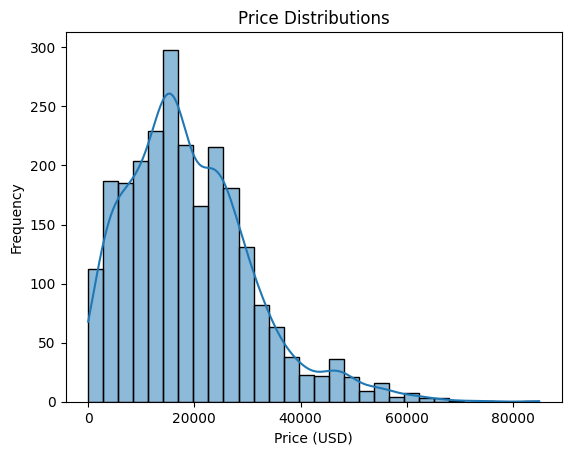

In [115]:
# Create a histogram showing the distribution of car prices.

plt.figure()
sns.histplot(df_clean['price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()


Price distribution is right-skewed: most vehicles are in the lower price range, with a small number of high-priced outliers.

In [53]:
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound)]

display (outliers.shape[0] ) #64 cars have outlier prices

print(f'Lower bound: ${lower_bound:,.0f}')
print(f'Upper bound: ${upper_bound:,.0f}')

64

Lower bound: $-12,450
Upper bound: $48,750


Cars priced above $48,750 are outliers (premium cars or special models).


It's important to remember that an expensive car isn't necessarily a mistake.

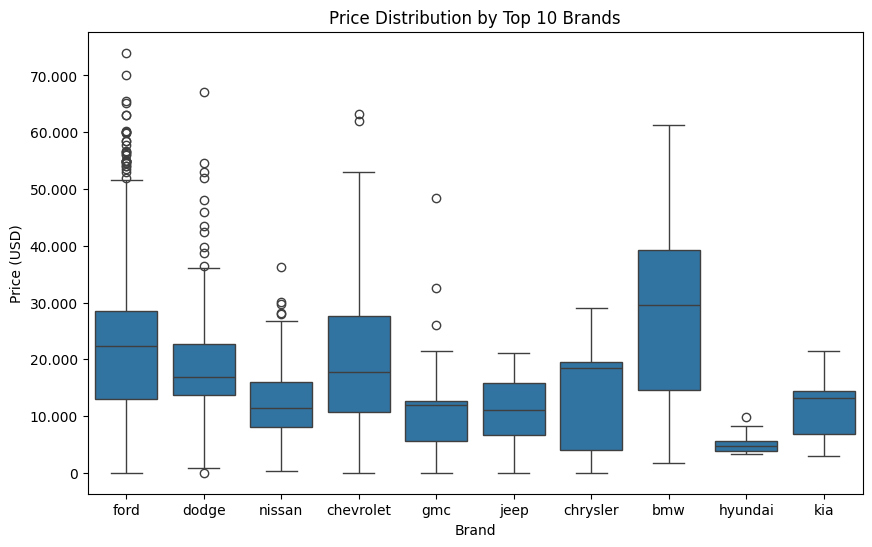

In [70]:
# Create a box plot showing price distribution by brand (top 10 brands).

# Count cars by brand
brand_counts = df_clean['brand'].value_counts()

# Filter brands with at least 1 car
brands_with_data = brand_counts[brand_counts > 0].index

# Top 10 brands
top_brands = df_clean['brand'].value_counts().loc[brands_with_data].nlargest(10).index

# Filter only those brands
df_top = df_clean[df_clean['brand'].isin(top_brands)]

# Ensure that the order of axis marks matches those with data
brand_order = df_top['brand'].value_counts().loc[top_brands].index

# Function for formatting with thousands separator
formatter = FuncFormatter(lambda x, pos: f'{int(x):,}'.replace(',', '.'))

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(x='brand', y='price', data=df_top, order=brand_order)
plt.title('Price Distribution by Top 10 Brands')
plt.xlabel('Brand')
plt.ylabel('Price (USD)')
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()

Car prices vary significantly by brand.

- Popular brands like Ford and Chevrolet have a wide price range.

- BMW is a premium brand with higher median prices.

- Hyundai is the most affordable brand.

In [111]:
# Create an interactive scatter plot of Price vs. Mileage, color-coded by Condition.

fig = px.scatter(
    df_clean,
    x='mileage',
    y='price',
    color='condition',
    hover_data=['brand', 'model', 'year'],  # Additional info when hovering
    title="Interactive Scatter Plot - Price vs Mileage (colored by Condition)"
)
fig.show()

correlation = df_clean['mileage'].corr(df_clean['price'])
print(f'Correlation between mileage and price: {correlation:.2f}')


Correlation between mileage and price: -0.39


Moderate negative correlation: Cars with higher miles tend to be cheaper, although there is some variation.


There are 3 cars in the 0.9M ~ 1.02M mileage range, well to the right of the scatter plot, that should be checked.

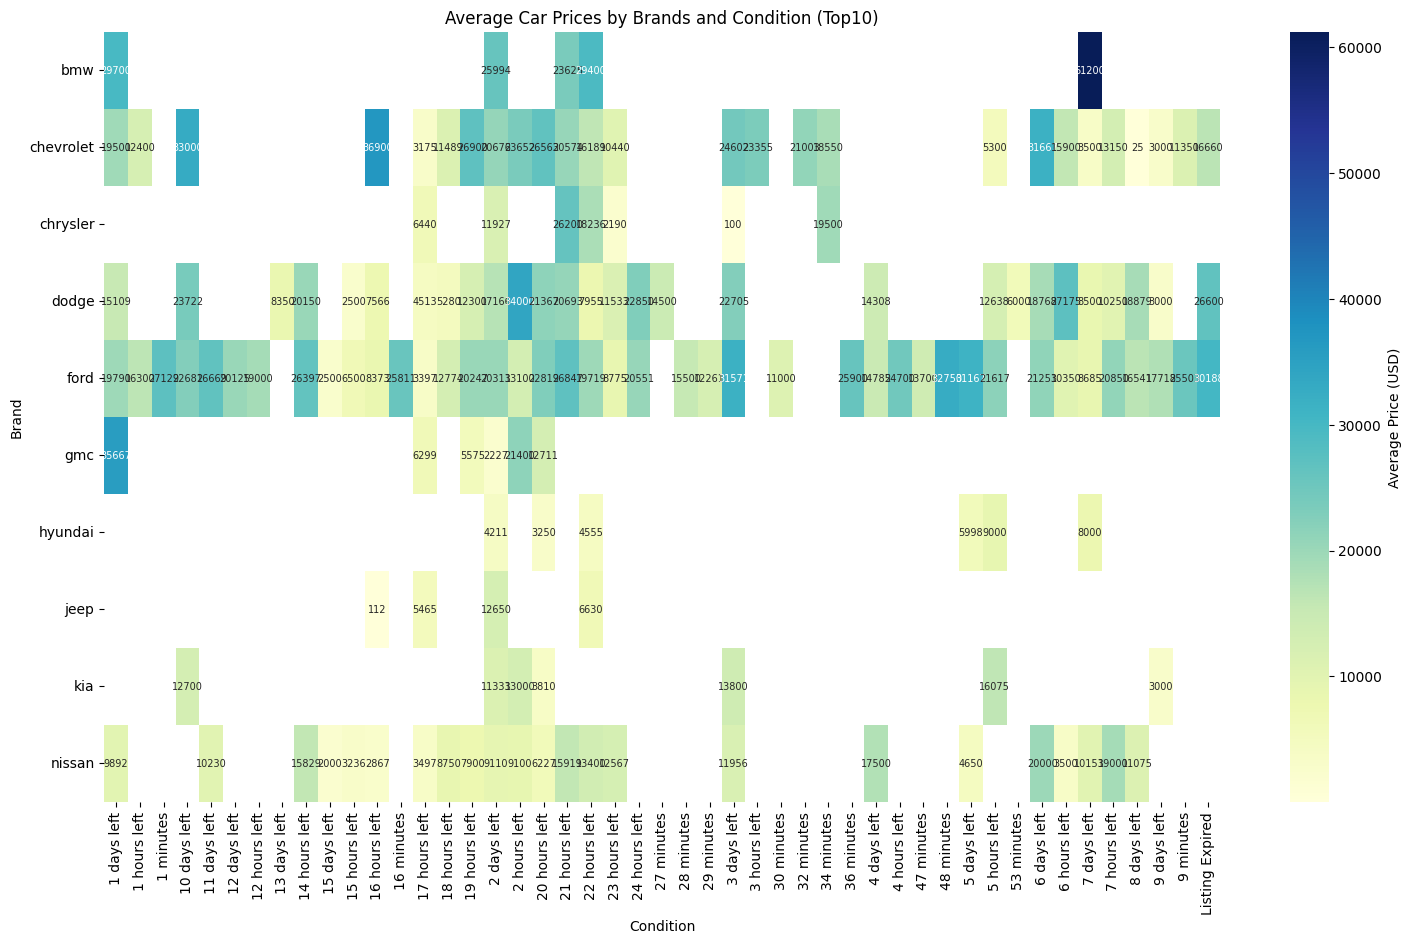

In [113]:
# Optional: create a heatmap of average prices by brand and condition.

#limit to the top 10 brands by number of cars (same as boxplot)

# Top 10 brands
top_brands = df_clean['brand'].value_counts().nlargest(10).index

# Filter dataset only with those brands
df_top = df_clean[df_clean['brand'].isin(top_brands)]

# Pivot table: rows = brands, columns = condition, value = average price
pivot = df_top.pivot_table(
    index='brand',
    columns='condition',
    values='price',
    aggfunc='mean',
    observed=True   #only present categories
)

plt.figure(figsize=(18,10))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='YlGnBu', cbar_kws={'label': 'Average Price (USD)'},   annot_kws={"size": 7} )
plt.title('Average Car Prices by Brands and Condition (Top10)')
plt.ylabel('Brand')
plt.xlabel('Condition')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

The combination of premium brand + good condition should generates the highest prices.